In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pyshtools as pysh
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
import os 
from meshplot import plot, subplot 
import anndata as ad
import pandas as pd

import igl 
from scipy.sparse.linalg import eigsh
from scipy import sparse 
from tqdm import tqdm
from sklearn.neighbors import NearestNeighbors

from scipy.special import digamma, gamma

# Set OpenBLAS to single thread to avoid memory conflicts
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['NUMEXPR_NUM_THREADS'] = '1'
os.environ['OMP_NUM_THREADS'] = '1'

In [3]:
import importlib

import src.meshharm
import src.fatemarkers
importlib.reload(src.meshharm)
importlib.reload(src.fatemarkers)


from src import utils 
from src.fatemarkers import FateMarkers
from src.ksg_estimators import KSGEstimator

In [4]:
path = 'Data/20250818/fractal_output/'

timepoints = ['day1p5', 'day2', 'day2p5', 'day3', 'day3p5', 'day4', 'day4p5', 'day4p5-more']

zarr_names = {
        'day1p5': 'r0.zarr',
        'day2':'r0.zarr',
        'day2p5':'r0.zarr',
        'day3':'r0.zarr',
        'day3p5':'r0.zarr',
        'day4':'r0.zarr',
        'day4p5':'r0.zarr',
        'day4p5-more':'r0.zarr',
}


wells = {
    'day1p5': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day2': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day2p5': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day3': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'B02', 'B03'],
    'day3p5': ['A01', 'A02', 'A03', 'A04', 'B03'],
    'day4': ['A02', 'A03', 'A04', 'A05', 'A06', 'B01', 'B02'],
    'day4p5': ['A06', 'B06'],
    'day4p5-more': ['C01', 'C02', 'C03', 'C04', 'C05', 'C06'],
}

rounds = {
    'day1p5': ['0_fused_zillum_registered'],
    'day2': ['0_fused_zillum_registered'],
    'day2p5': ['0_fused_zillum_registered'],
    'day3': ['0_fused_zillum_registered'],
    'day3p5': ['0_fused_zillum_registered'],
    'day4': ['0_fused_zillum_registered'],
    'day4p5': ['0_fused_zillum_registered'],
    'day4p5-more': ['0_fused_zillum_registered'],
}



times_dic = {
    '1p5': 1.5,
    '2': 2,
    '2p5': 2.5,
    '3': 3,
    '3p5': 3.5,
    '4': 4,
    '4p5': 4.5,
    '4p5-more': 4.5
}

In [5]:
res = np.load('sim/vocab.npz', allow_pickle=True)
vocab = res['vocab']
scaler = res['scalar'].item() 
sigma = res['sigma']
ts = res['ts']

def load(save_path): 
    m = FateMarkers()
    m.load_results(save_path)
    frac = m.compute_recon_quality()
    hks = [] 
    for t in ts:
        x = np.einsum('i, ji->j', np.exp(-m.eigvals*t), m.eigvecs**2)
        hks.append(x) 
    hks = np.array(hks).T 
    hks_scaled = scaler.transform(hks)
    dist = np.linalg.norm(hks_scaled[:, np.newaxis, :]- vocab[np.newaxis, :, :], axis=2)
    encoding = np.exp(-dist**2 / (2 * sigma**2))

    coeffs_hks = m.eigvecs.T @ (m.mass_matrix @ encoding)
    return m.coeffs_fm[:], coeffs_hks, frac

In [ ]:
coeffs_hks = [] 
coeffs_fm = [] 
times = [] 
fracs = []


for timepoint in timepoints:
    zarr_name = zarr_names[timepoint]
    for well_name in wells[timepoint]:
        round_name = rounds[timepoint][0]

        file_path = f"{path}{timepoint}/{zarr_name}/{well_name[0]}/{well_name[1:]}/{round_name}/"
        labels = np.load(file_path + 'good_labels.npy').astype('int')
        print(file_path) 
        for label in tqdm(labels):
            save_path = f"{file_path}/fm_data/{label}"
            if os.path.exists(save_path + '_coeffs.npz'):
                c1, c2, frac = load(save_path)
                coeffs_fm.append(c1)
                coeffs_hks.append(c2)
                times.append(timepoint[3:6])
                fracs.append(frac)

Data/20250818/fractal_output/day1p5/r0.zarr/A/01/0_fused_zillum_registered/


100%|██████████| 117/117 [00:40<00:00,  2.91it/s]


Data/20250818/fractal_output/day1p5/r0.zarr/A/02/0_fused_zillum_registered/


100%|██████████| 56/56 [00:26<00:00,  2.13it/s]


Data/20250818/fractal_output/day1p5/r0.zarr/A/03/0_fused_zillum_registered/


...

100%|██████████| 53/53 [00:13<00:00,  3.85it/s]


Data/20250818/fractal_output/day4/r0.zarr/A/05/0_fused_zillum_registered/


100%|██████████| 61/61 [00:15<00:00,  4.04it/s]


Data/20250818/fractal_output/day4/r0.zarr/A/06/0_fused_zillum_registered/


 15%|█▌        | 12/80 [00:03<00:17,  3.91it/s]

In [62]:
threshold = np.percentile(fracs, 95)
recon_mask = np.array(fracs) < threshold
filtered_times = np.array(times)[recon_mask]
filtered_hks = np.array(coeffs_hks)[recon_mask]

In [63]:

coeffs_fm_filtered = np.array(coeffs_fm)[recon_mask]
print(coeffs_fm_filtered.shape)

m = FateMarkers()
m.load_results(save_path)
fm_names = m.field_names
print(fm_names) 

fm_of_interest = [name for name in fm_names if name.endswith('percentile95')]
fm_dict = {
    '0.C01': 'DAPI (nuclei)', 
    '0.C02': 'LGR5 (stem cells)', 
    '0.C03': 'Chromogranin A (enteroendocrine secretory progenitors)', 
    '0.C04': 'Cyclin D (cycling cells, G1 phase)', 
    '1.C01': 'DAPI (nuclei)', 
    '1.C02': 'B-catenin (membrane)', 
    '1.C03': 'Mucin 2 (goblet secretory cells)', 
    '1.C04': 'AldoB (enterocyte absorptive cells, G1 phase)', 
    '2.C01': 'DAPI (nuclei)', 
    '2.C02': 'Glucagon (enteroendocrine secretory cells)', 
    '2.C03': 'Cyclin A (cycling cell, G2/S phase)', 
    '2.C04': 'Agr2 (all secretory progenitors)', 
    '3.C01': 'DAPI (nuclei)',
    '3.C02': 'Serotonin (enteroendocrine secretory cells)', 
    '3.C03': 'Lysozyme (panted cells)', 
    '4.C01': 'DAPI (nuclei)', 
    '4.C02': 'CF488 (z-illumination control)', 
    '4.C03': 'CF568 (z-illumination control)', 
    '4.C04': 'AF647 (z-illumination control)', 
}

indices = [fm_names.index(e) for e in fm_of_interest if fm_dict[e[:5]] != 'DAPI (nuclei)']
final_names = [fm_dict[e[:5]] for e in fm_of_interest if fm_dict[e[:5]] != 'DAPI (nuclei)']

coeffs_fm_filtered = coeffs_fm_filtered[:, :, indices]

(664, 225, 43)
['4.label', '4.C01.mean_intensity', '4.C01.percentile95', '4.C02.mean_intensity', '4.C02.percentile95', '4.C03.mean_intensity', '4.C03.percentile95', '4.C04.mean_intensity', '4.C04.percentile95', '1.label', '1.C01.mean_intensity', '1.C01.percentile95', '1.C02.mean_intensity', '1.C02.percentile95', '1.C03.mean_intensity', '1.C03.percentile95', '1.C04.mean_intensity', '1.C04.percentile95', '2.label', '2.C01.mean_intensity', '2.C01.percentile95', '2.C02.mean_intensity', '2.C02.percentile95', '2.C03.mean_intensity', '2.C03.percentile95', '2.C04.mean_intensity', '2.C04.percentile95', '0.label', '0.C01.mean_intensity', '0.C01.percentile95', '0.C02.mean_intensity', '0.C02.percentile95', '0.C03.mean_intensity', '0.C03.percentile95', '0.C04.mean_intensity', '0.C04.percentile95', '3.label', '3.C01.mean_intensity', '3.C01.percentile95', '3.C02.mean_intensity', '3.C02.percentile95', '3.C03.mean_intensity', '3.C03.percentile95']


In [70]:
coeffs = np.concatenate([np.array(coeffs_fm_filtered), filtered_hks], axis=-1)

hks_names = [f'hks{i}' for i in range(filtered_hks.shape[-1])]
names = final_names + hks_names 

In [ ]:
ksg = KSGEstimator()

coeffs_rescaled = np.empty_like(coeffs) 

for i in range(coeffs.shape[-1]):
    scaler = StandardScaler()
    coeffs_rescaled[:, :, i] = scaler.fit_transform(coeffs[:, :, i])

matrices = [] 
for t in np.unique(times): 
    mask = (filtered_times == t) 
    print(int(np.sum(mask)), t)
    mi_matrix = np.zeros((coeffs.shape[-1], coeffs.shape[-1]))
    masked_coeffs = coeffs_rescaled[mask, :, :] 
    for i in range(coeffs.shape[-1]): 
        for j in range(0, i+1): 

            X = np.copy(masked_coeffs[:, :, i])
            Y = np.copy(masked_coeffs[:, :, j])
            mi_matrix[i, j] = ksg.mutual_information(X, Y, method=2)
            mi_matrix[j, i] = mi_matrix[i, j]
    matrices.append(mi_matrix)


NameError: name 'KSGEstimator' is not defined

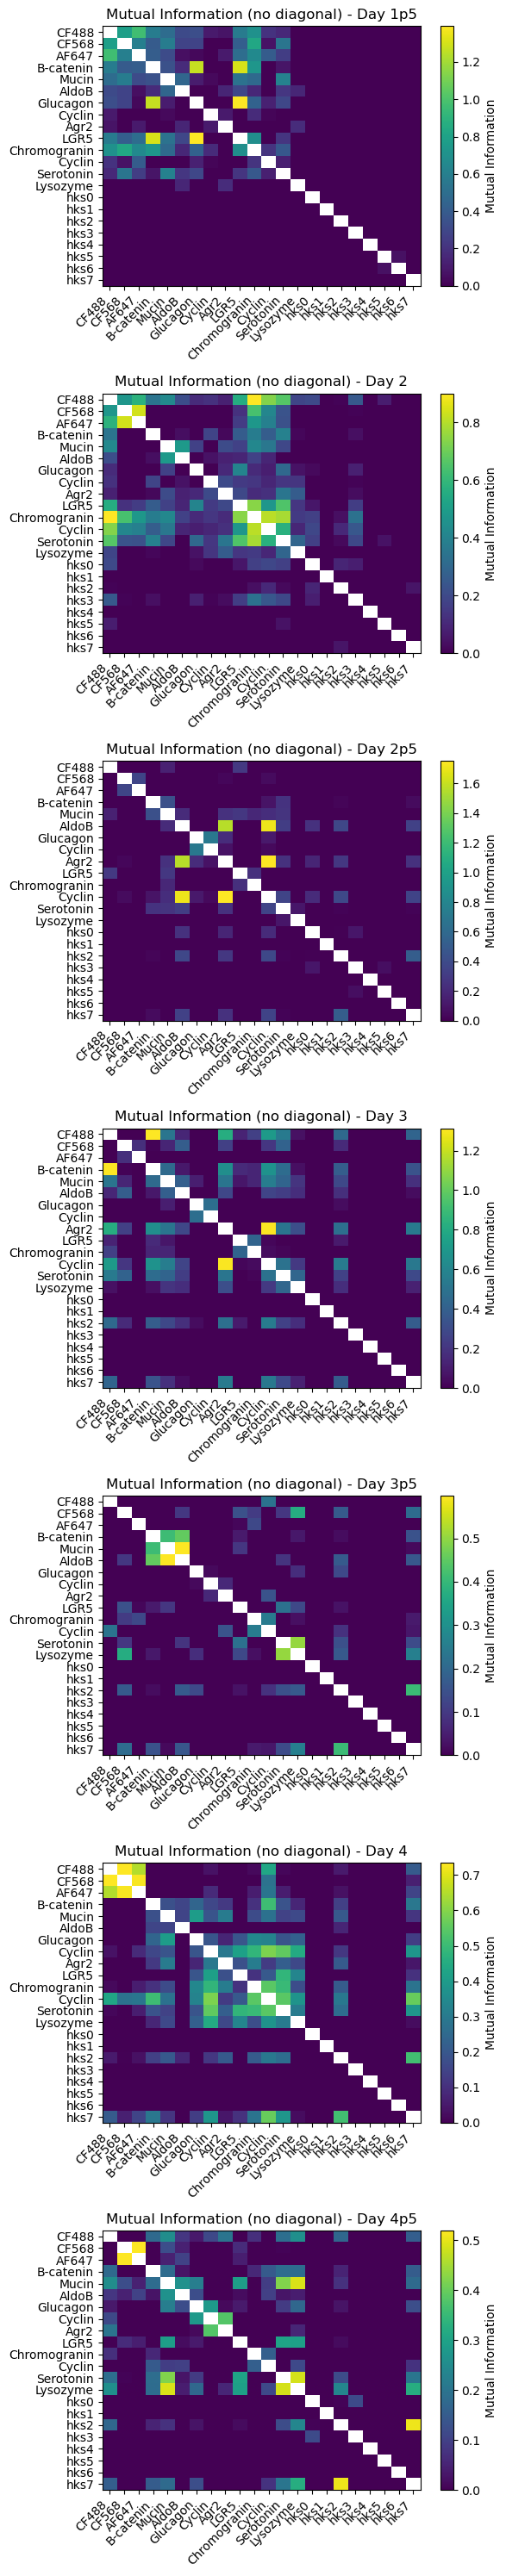

In [83]:
# Loop over all matrices for each timepoint
unique_times_list = np.unique(times)
n_timepoints = len(unique_times_list)

short_names = [names.split(' ')[0] for names in names]

fig, axes = plt.subplots(len(unique_times_list), 1, figsize=(6, 30))

for idx, (mi_matrix, timepoint) in enumerate(zip(matrices, unique_times_list)):
    n_features = mi_matrix.shape[0]
    
    # Plot 2: Without diagonal elements
    mask = np.eye(n_features, dtype=bool)
    mi_matrix_masked = np.copy(mi_matrix)
    mi_matrix_masked[mask] = np.nan

    im2 = axes[idx].imshow(mi_matrix_masked, cmap='viridis', aspect='auto')
    plt.colorbar(im2, ax=axes[idx], label='Mutual Information')
    axes[idx].set_xticks(ticks=np.arange(n_features))
    axes[idx].set_xticklabels(short_names, rotation=45, ha='right')
    axes[idx].set_yticks(ticks=np.arange(n_features))
    axes[idx].set_yticklabels(short_names)
    axes[idx].set_title(f'Mutual Information (no diagonal) - Day {timepoint}')

plt.tight_layout()
plt.show()

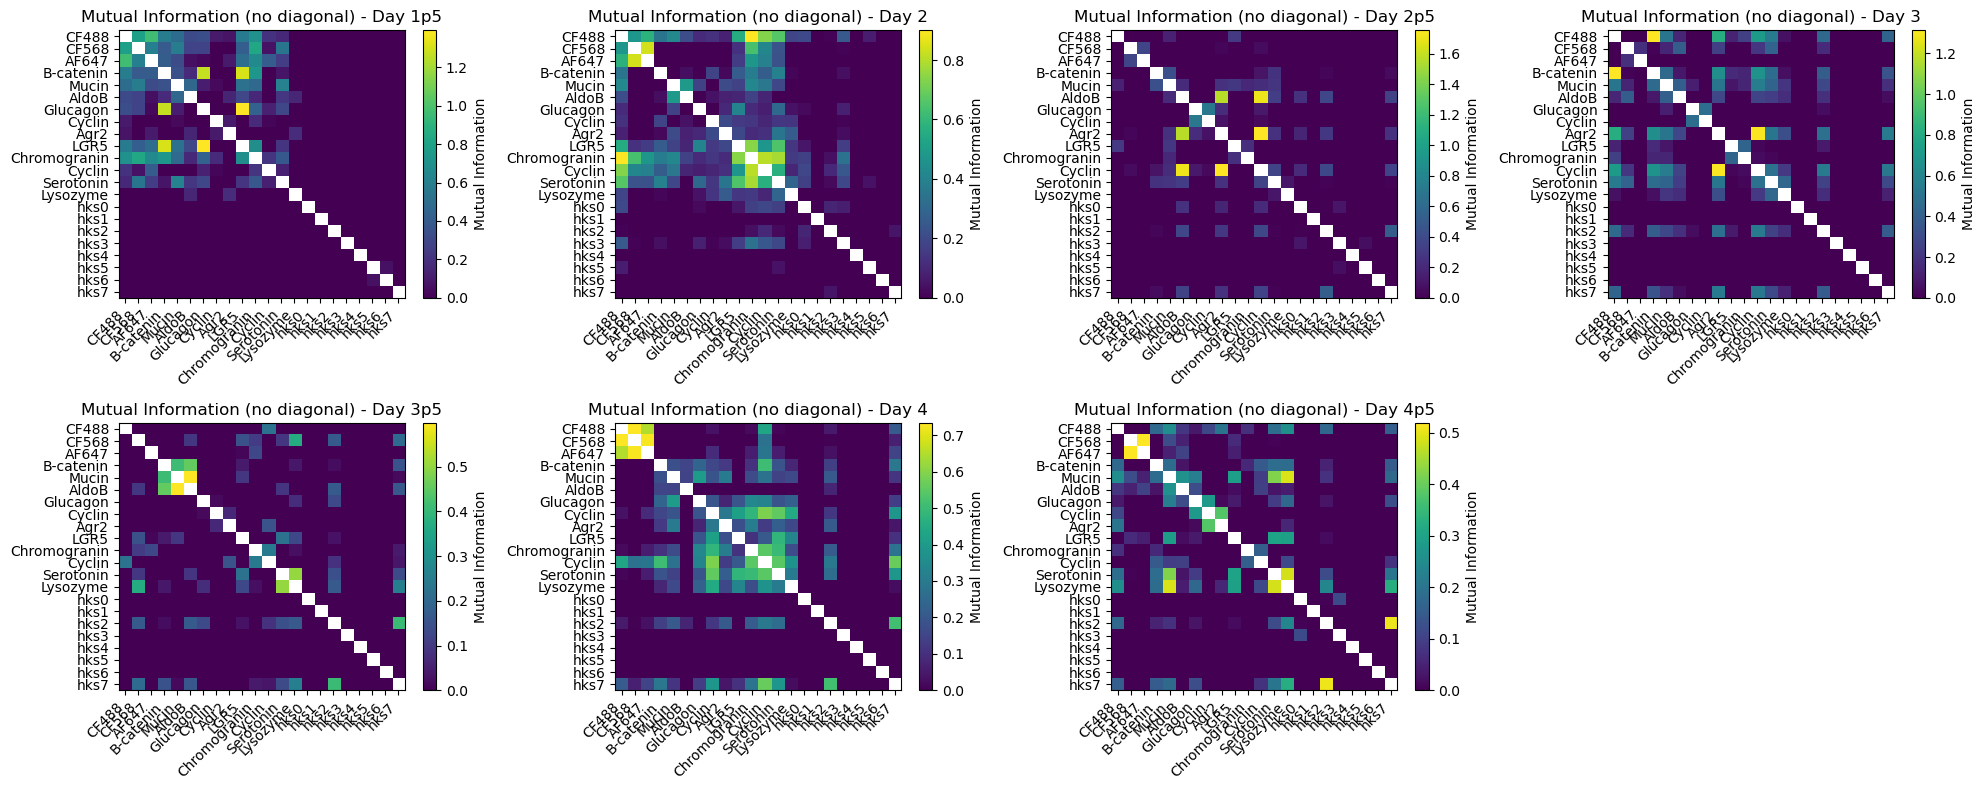

In [82]:
import math

# Loop over all matrices for each timepoint
unique_times_list = np.unique(times)
n_timepoints = len(unique_times_list)

short_names = [names.split(' ')[0] for names in names]

# Calculate number of rows needed for 2 columns
n_cols = 4
n_rows = math.ceil(n_timepoints / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()  # Flatten in case axes is 2D

for idx, (mi_matrix, timepoint) in enumerate(zip(matrices, unique_times_list)):
    n_features = mi_matrix.shape[0]
    
    # Plot 2: Without diagonal elements
    mask = np.eye(n_features, dtype=bool)
    mi_matrix_masked = np.copy(mi_matrix)
    mi_matrix_masked[mask] = np.nan

    im2 = axes[idx].imshow(mi_matrix_masked, cmap='viridis', aspect='auto')
    plt.colorbar(im2, ax=axes[idx], label='Mutual Information')
    axes[idx].set_xticks(ticks=np.arange(n_features))
    axes[idx].set_xticklabels(short_names, rotation=45, ha='right')
    axes[idx].set_yticks(ticks=np.arange(n_features))
    axes[idx].set_yticklabels(short_names)
    axes[idx].set_title(f'Mutual Information (no diagonal) - Day {timepoint}')

# Hide any unused subplots
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

(180, 22)


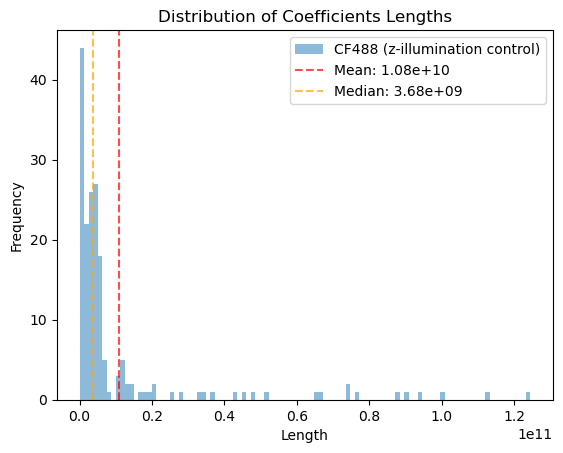

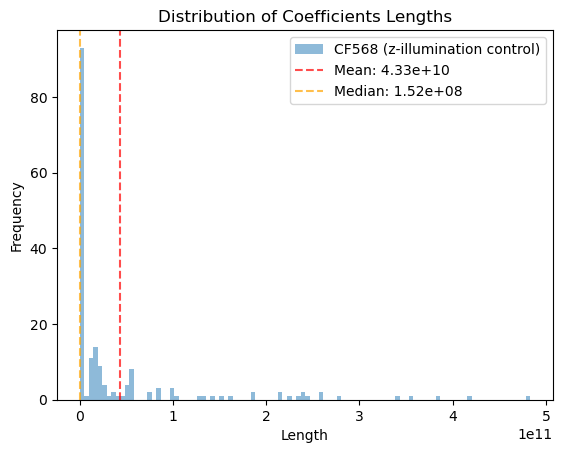

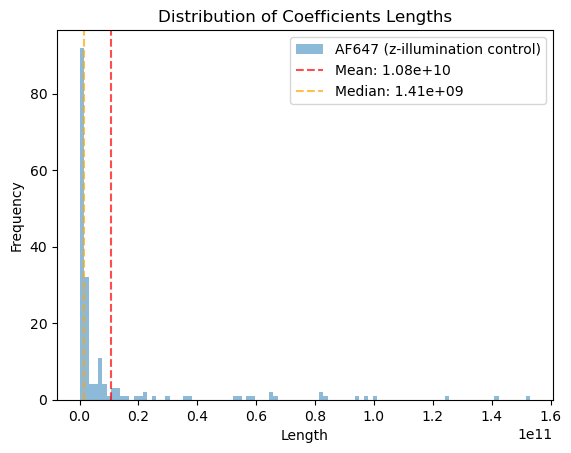

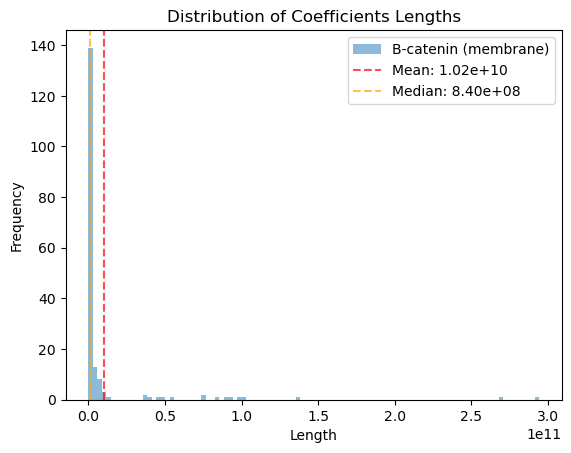

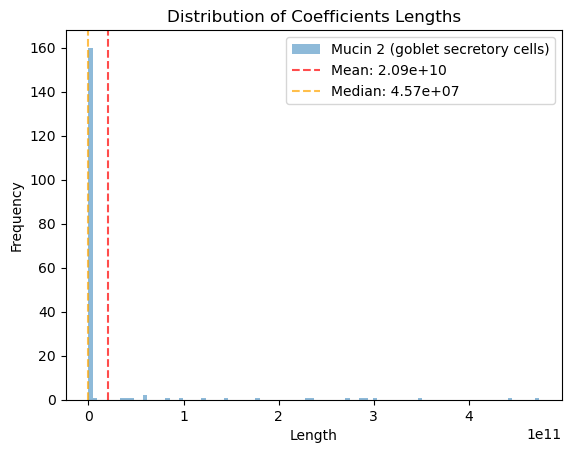

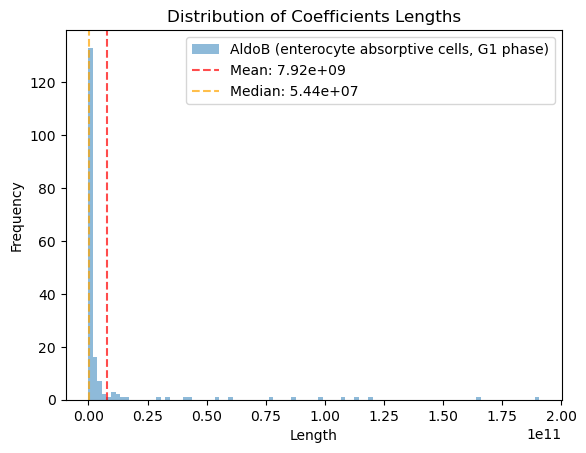

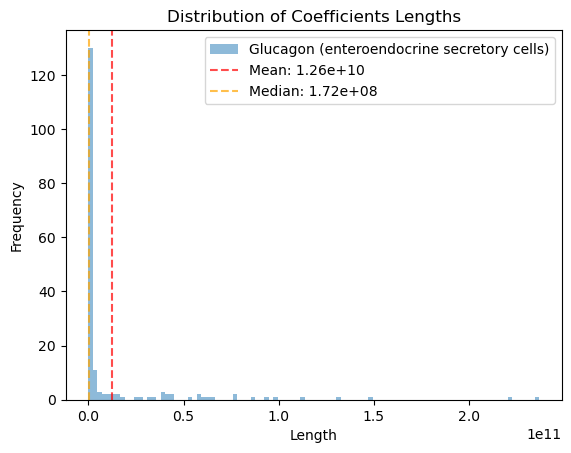

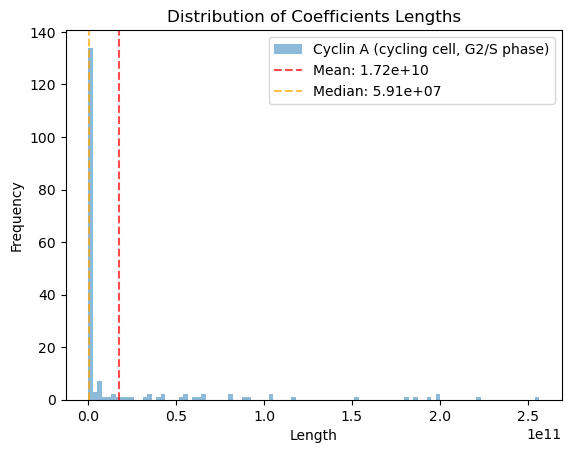

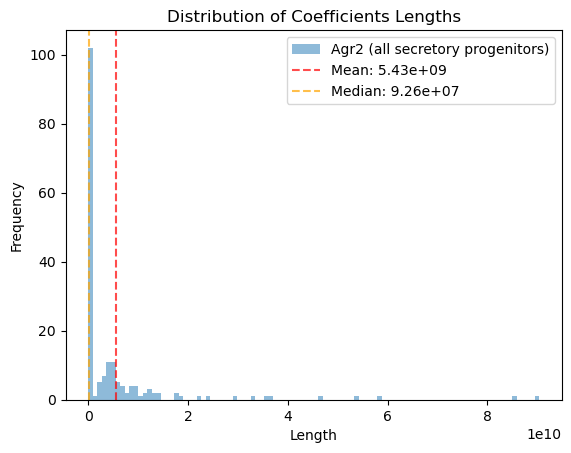

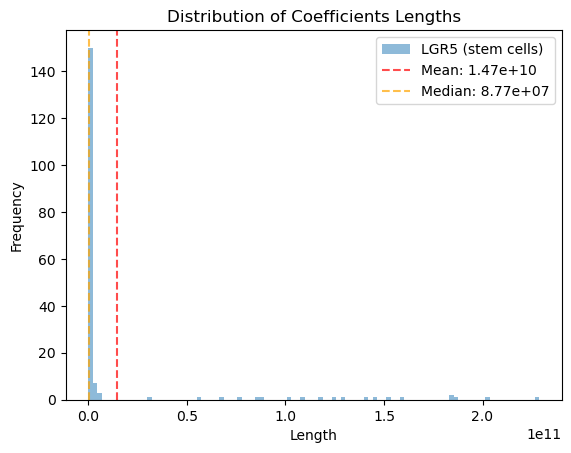

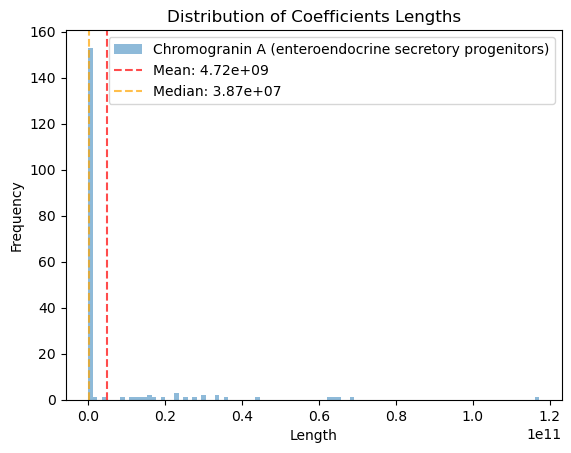

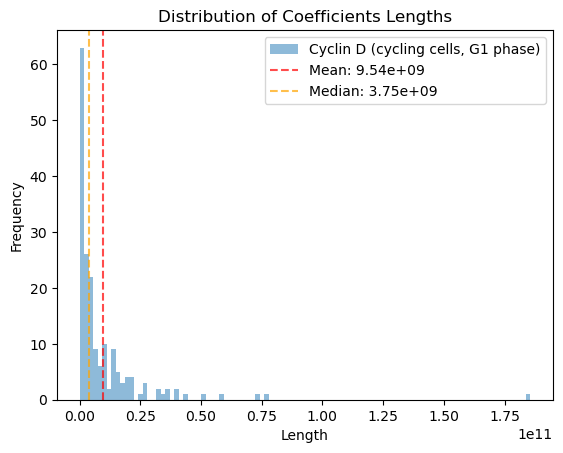

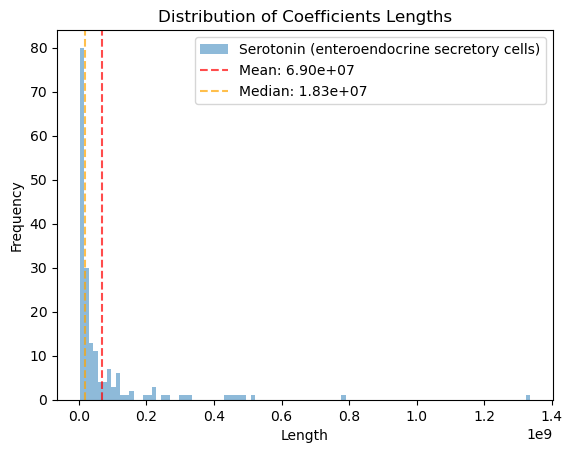

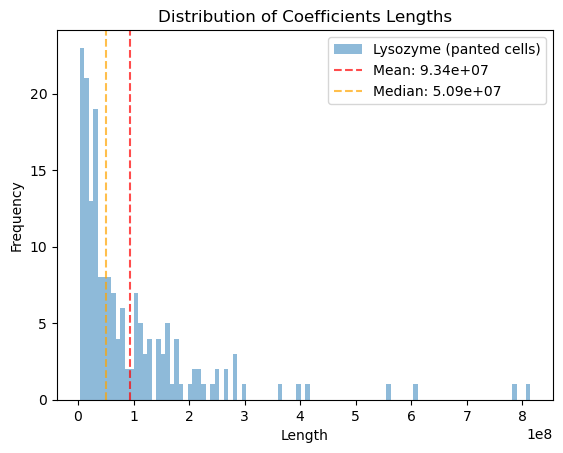

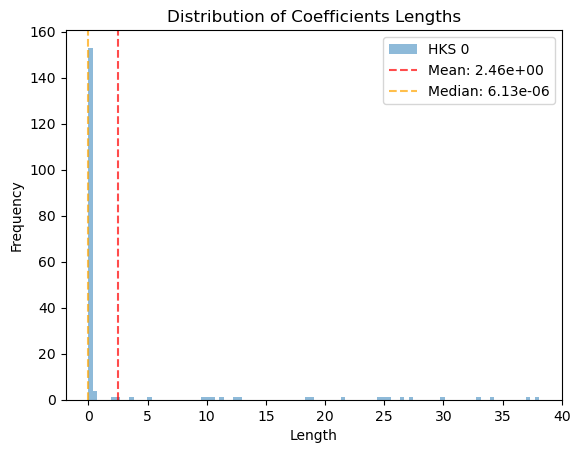

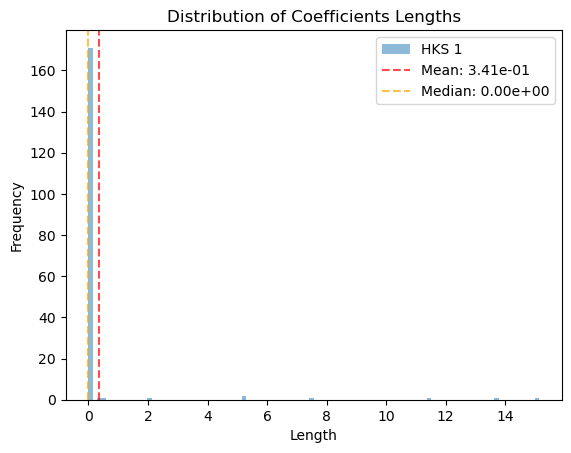

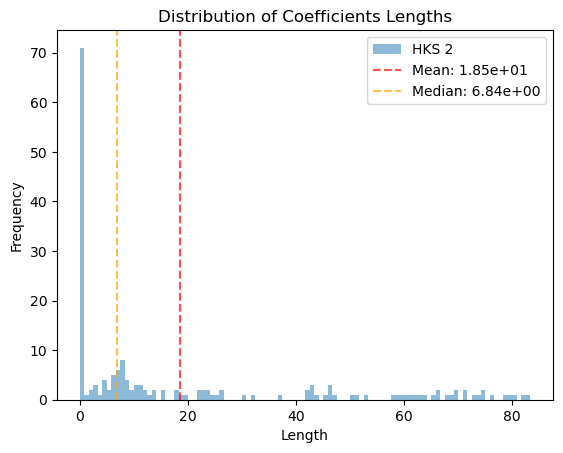

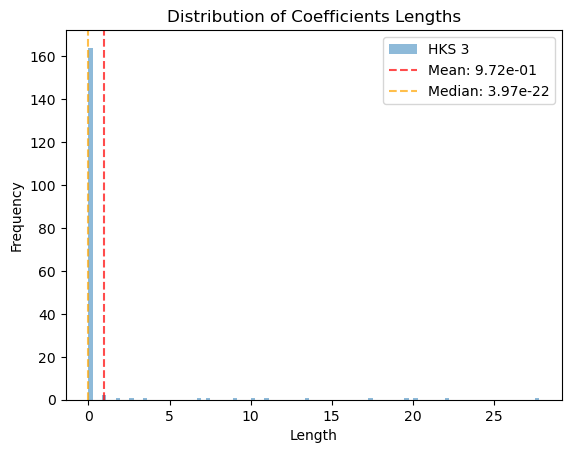

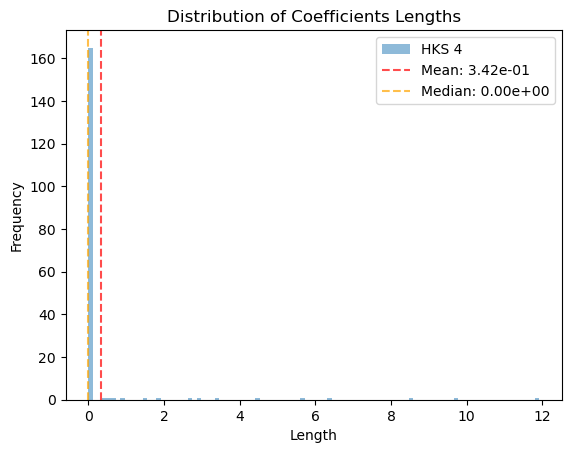

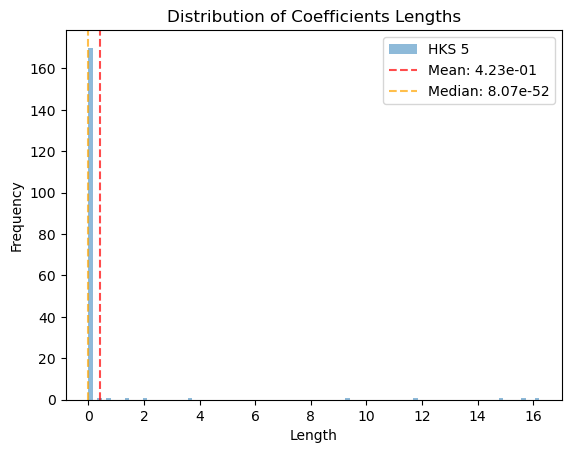

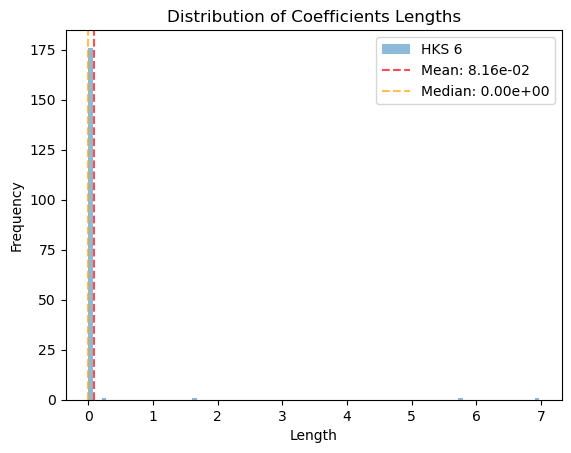

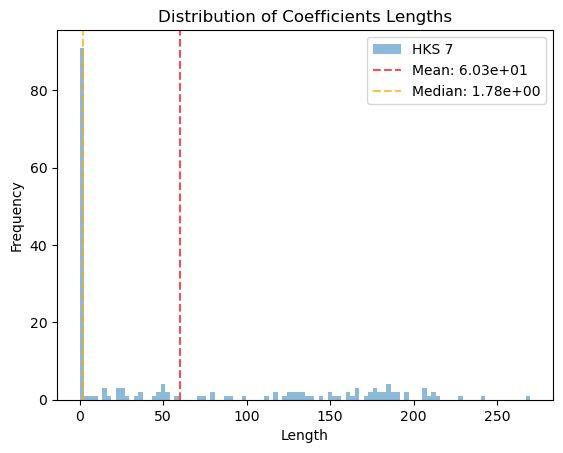

In [53]:

lengths = np.sum(coeffs * np.conjugate(coeffs), axis=1) 


print(lengths.shape) 
for i in range(coeffs.shape[-1]):
    plt.hist(lengths[:, i], bins=100, alpha=0.5, label=names[i])
    plt.axvline(np.mean(lengths[:, i]), color='red', linestyle='--', alpha=0.7, label=f'Mean: {np.mean(lengths[:, i]):.2e}')
    plt.axvline(np.median(lengths[:, i]), color='orange', linestyle='--', alpha=0.7, label=f'Median: {np.median(lengths[:, i]):.2e}')
    plt.xlabel('Length')
    plt.ylabel('Frequency')
    plt.title('Distribution of Coefficients Lengths')
    plt.legend()
    plt.show()